# Tessellating Different Cities

This notebook demonstrates how the implemented tessellation methods function for different cities. We select a wide variety of cities on different continents. For example, cities that consist of multipolygons and islands are also considered.

Selected cities are `Barcelona`, `Key West`, `Nairobi`, `Tehran`.

To run this notebook, in addition to `tesspy`, you need `contextily` for basemap visualization. This package is only used to enhance visualization and has no effect on tessellation.

In [ ]:
from tesspy import Tessellation
import matplotlib.pyplot as plt
import contextily as ctx

## Getting city polygons

In [ ]:
# Create a tessellation object for each city
barcelona = Tessellation("Barcelona, Spain")
key_west = Tessellation("Key West, United States")
nairobi = Tessellation("Nairobi, Kenya")
tehran = Tessellation("Tehran, Iran")

# get polygon of the investigated area
barcelona_polygon = barcelona.get_polygon()
key_west_polygon = key_west.get_polygon()
nairobi_polygon = nairobi.get_polygon()
tehran_polygon = tehran.get_polygon()

In [ ]:
# visualization of areas
cities_polygons = [barcelona_polygon, key_west_polygon, nairobi_polygon, tehran_polygon]
cities_names = [
    "Barcelona, Spain",
    "Key West, United States",
    "Nairobi, Kenya",
    "Tehran, Iran",
]

fig, axs = plt.subplots(2, 2, figsize=(20, 15))

for ax, city_polygon, city_name in zip(axs.flatten(), cities_polygons, cities_names):
    city_polygon.to_crs("EPSG:3857").plot(ax=ax, facecolor="none", lw=3)
    ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()
    ax.set_title(city_name, fontsize=20)

plt.tight_layout()

## Squares

In [16]:
# Creating square tessellation

barcelona_squares = barcelona.squares(14)
key_west_squares = key_west.squares(16)
nairobi_squares = nairobi.squares(14)
tehran_squares = tehran.squares(14)

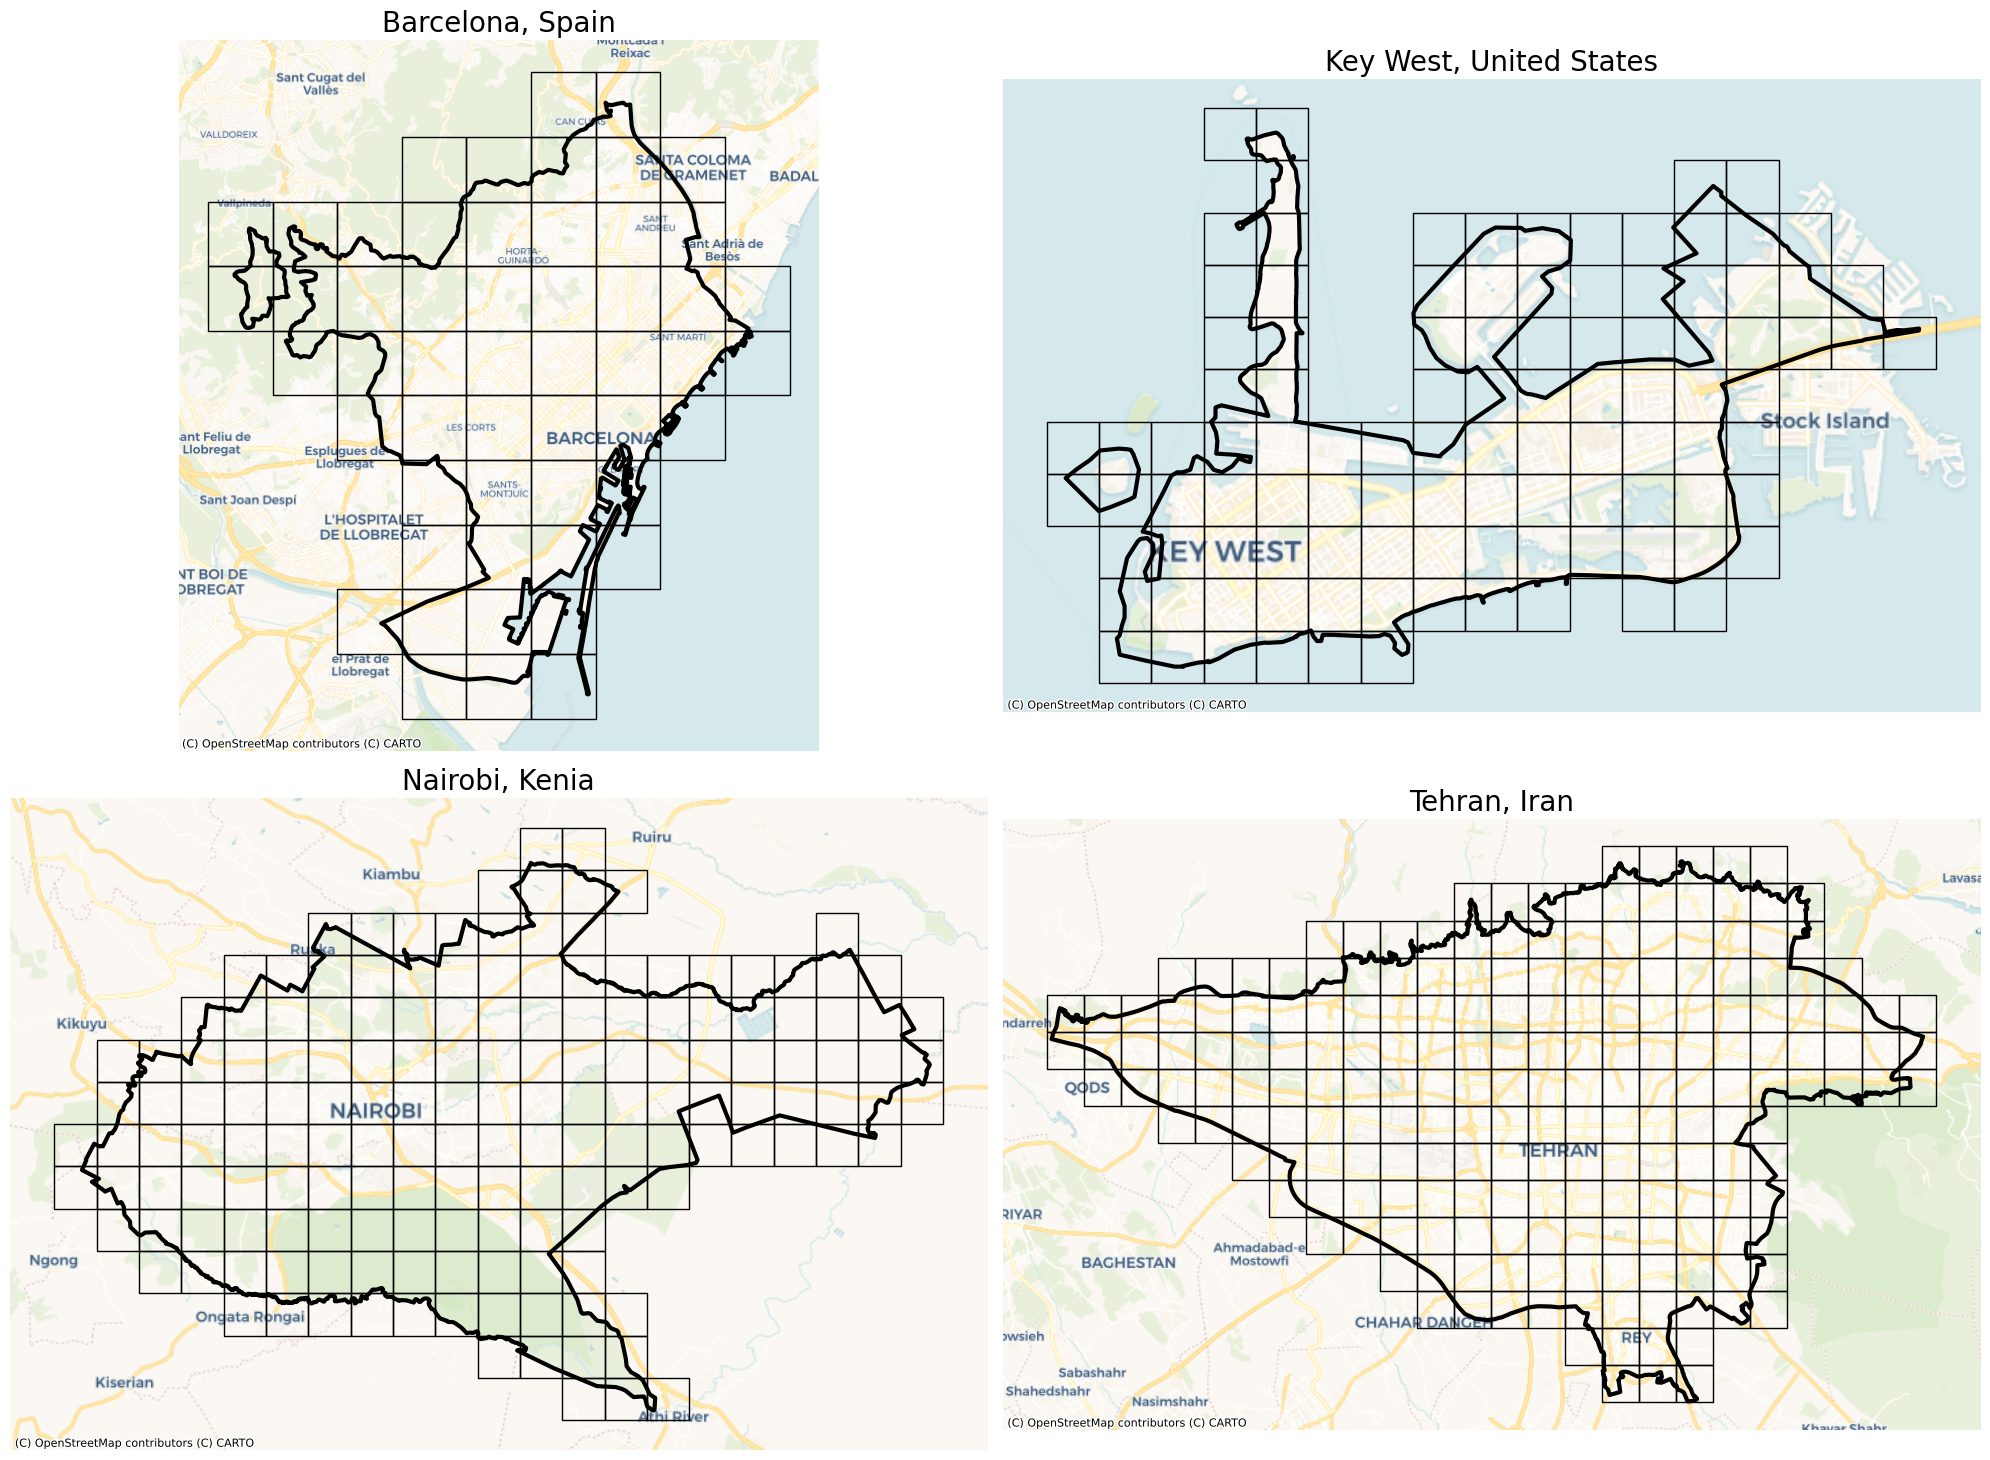

In [17]:
# visualization of square tessellation

cities_squares = [barcelona_squares, key_west_squares, nairobi_squares, tehran_squares]

fig, axs = plt.subplots(2, 2, figsize=(20, 15))

for ax, city_polygon, city_name, city_square in zip(
    axs.flatten(), cities_polygons, cities_names, cities_squares
):
    city_square.to_crs("EPSG:3857").plot(ax=ax, facecolor="none", edgecolor="k", lw=1)
    city_polygon.to_crs("EPSG:3857").plot(ax=ax, facecolor="none", edgecolor="k", lw=3)
    ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()
    ax.set_title(city_name, fontsize=20)

plt.tight_layout()

## Hexagons

In [18]:
# Creating hexagons tessellation

barcelona_hexagons = barcelona.hexagons(8)
key_west_hexagons = key_west.hexagons(9)
nairobi_hexagons = nairobi.hexagons(7)
tehran_hexagons = tehran.hexagons(7)

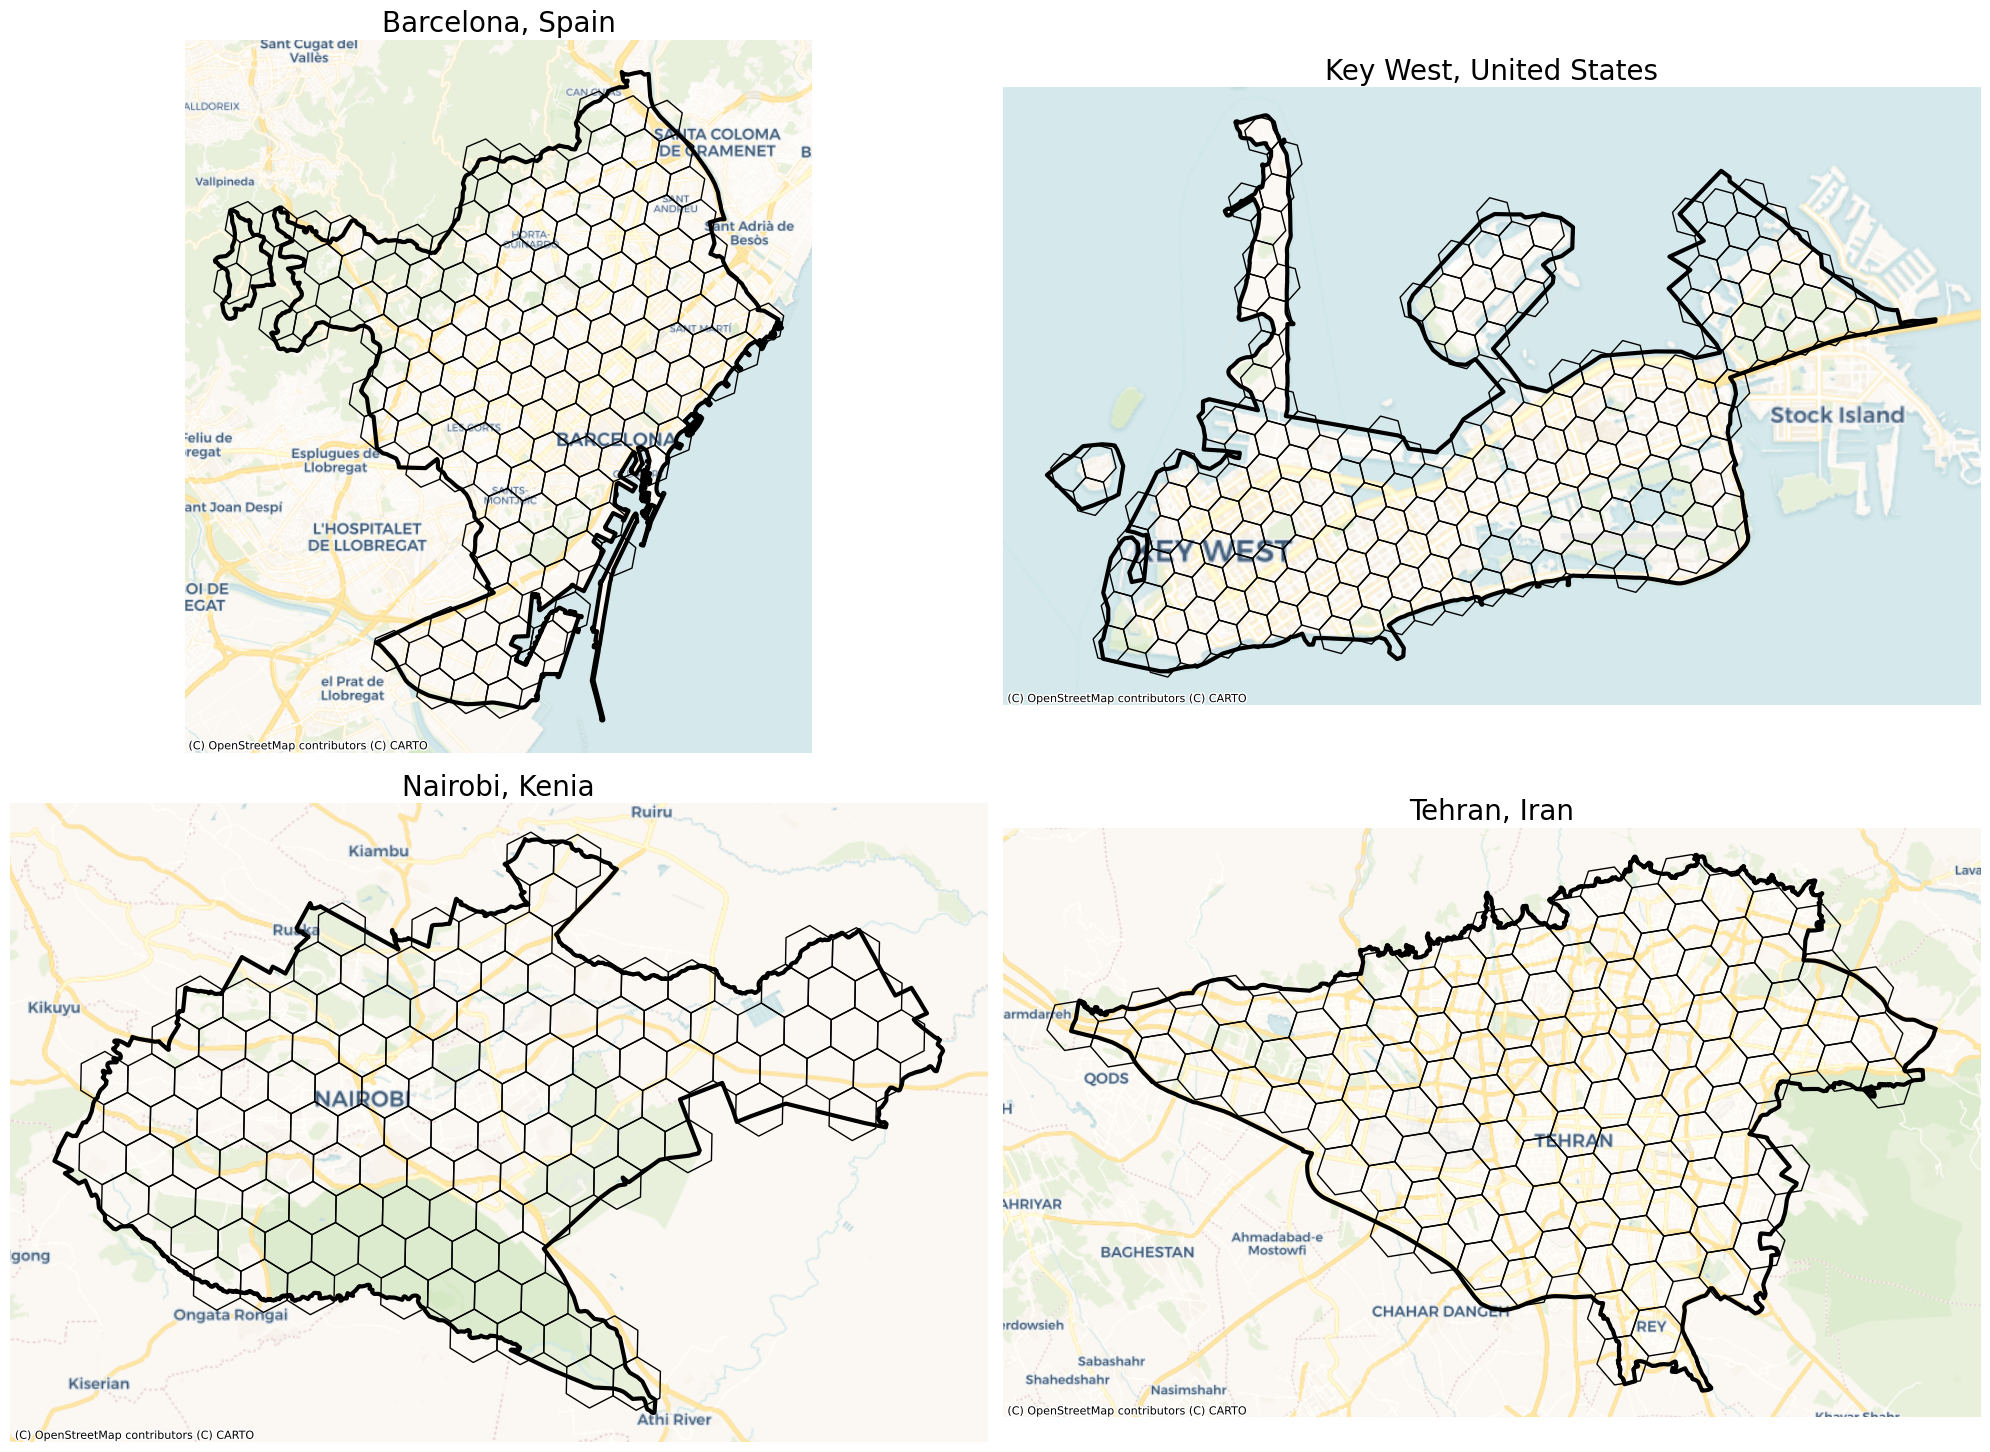

In [19]:
# visualization of hexagons tessellation

cities_hexagons = [
    barcelona_hexagons,
    key_west_hexagons,
    nairobi_hexagons,
    tehran_hexagons,
]

fig, axs = plt.subplots(2, 2, figsize=(20, 15))

for ax, city_polygon, city_name, city_hexagon in zip(
    axs.flatten(), cities_polygons, cities_names, cities_hexagons
):
    city_hexagon.to_crs("EPSG:3857").plot(ax=ax, facecolor="none", edgecolor="k", lw=1)
    city_polygon.to_crs("EPSG:3857").plot(ax=ax, facecolor="none", edgecolor="k", lw=3)
    ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()
    ax.set_title(city_name, fontsize=20)

plt.tight_layout()

## Adaptive squares

In [ ]:
# Creating adaptive squares tessellation

barcelona_asq = barcelona.adaptive_squares(
    start_resolution=14, poi_categories=["amenity"]
)
key_west_asq = key_west.adaptive_squares(
    start_resolution=15, poi_categories=["amenity"], threshold=40
)
nairobi_asq = nairobi.adaptive_squares(
    start_resolution=13, poi_categories=["amenity"], threshold=150
)
tehran_asq = tehran.adaptive_squares(
    start_resolution=13, poi_categories=["amenity"], threshold=100
)

## Voronoi Diagrams

In [ ]:
# Creating voronoi tessellation

barcelona_vor = barcelona.voronoi(n_polygons=100, poi_categories=["building"], timeout=180)
key_west_vor = key_west.voronoi(n_polygons=50, poi_categories=["building"], timeout=180)
nairobi_vor = nairobi.voronoi(n_polygons=200, poi_categories=["building"], timeout=180)
tehran_vor = tehran.voronoi(n_polygons=300, poi_categories=["building"], timeout=180)

## City Blocks

In [ ]:
# Creating city blocks tessellation
# Since it takes a lot of time, we only create the city blocks for two cities.

barcelona_blks = barcelona.city_blocks(n_polygons=500, detail_deg=11)
nairobi_blks = nairobi.city_blocks(n_polygons=500)